# Flight Delay Prediction Project

A structured machine learning pipeline for predicting US domestic flight delays, built on approximately 30 million flight records.

**Problems Addressed:**
- **Binary Classification:** Will a flight arrive more than 15 minutes late?
- **Regression:** For delayed flights, how many minutes is the arrival delay?

**Modeling Approach:** A two-stage strategy — classify delay occurrence first, then estimate severity only for predicted delayed flights.

---

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 50)

## 2. Data Loading

The dataset is stored as a Parquet file for efficient columnar access. We load it into a pandas DataFrame and preview the first few records.

In [3]:
df = pd.read_parquet('Flight_Delay.parquet')
df.head()

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,OriginCityName,DestCityName,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
1,2018,1,15,2018-01-15,UA,"Newark, NJ","Charleston, SC",1845,1928.0,43.0,43.0,35.0,2003.0,2145.0,4.0,2108,2149.0,41.0,41.0,143.0,141.0,102.0,628.0,3,41.0,0.0,0.0,0.0,0.0
2,2018,1,16,2018-01-16,UA,"Newark, NJ","Charleston, SC",1835,1956.0,81.0,81.0,18.0,2014.0,2202.0,5.0,2058,2207.0,69.0,69.0,143.0,131.0,108.0,628.0,3,67.0,0.0,0.0,0.0,2.0
3,2018,1,17,2018-01-17,UA,"Newark, NJ","Charleston, SC",1835,1836.0,1.0,1.0,19.0,1855.0,2048.0,6.0,2058,2054.0,-4.0,0.0,143.0,138.0,113.0,628.0,3,0.0,0.0,0.0,0.0,0.0
4,2018,1,18,2018-01-18,UA,"Newark, NJ","Charleston, SC",1845,1844.0,-1.0,0.0,36.0,1920.0,2052.0,6.0,2108,2058.0,-10.0,0.0,143.0,134.0,92.0,628.0,3,0.0,0.0,0.0,0.0,0.0
6,2018,1,20,2018-01-20,UA,"Newark, NJ","Charleston, SC",1835,1829.0,-6.0,0.0,22.0,1851.0,2020.0,6.0,2058,2026.0,-32.0,0.0,143.0,117.0,89.0,628.0,3,0.0,0.0,0.0,0.0,0.0


## 3. Initial Data Overview

A quick audit of the dataset's structure: shape, column types, and completeness.

In [4]:
print('Shape:', df.shape)

display(pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values
}).sort_values('missing_pct', ascending=False))

Shape: (30132672, 29)


,column,dtype,missing_count,missing_pct
0,Year,int64,0,0.0
15,CRSArrTime,int64,0,0.0
27,SecurityDelay,float64,0,0.0
26,NASDelay,float64,0,0.0
25,WeatherDelay,float64,0,0.0
24,CarrierDelay,float64,0,0.0
23,DistanceGroup,int64,0,0.0
22,Distance,float64,0,0.0
21,AirTime,float64,0,0.0
20,ActualElapsedTime,float64,0,0.0


## 4. Exploratory Data Analysis (EDA)

We explore the dataset to understand delay distributions and patterns across time of day, day of week, month, airline, route, and distance.

> **Note:** A minimal set of features (departure hour, month, day of week, airline name) is extracted in Section 4.0 to support EDA visualizations. The complete feature engineering pipeline is built in Section 5.

### 4.0 Pre-EDA Feature Extraction

Minimal preprocessing required to support EDA visualizations. These features are fully re-derived and extended in Section 5.

In [5]:
# Convert FlightDate to datetime and extract calendar components
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['month'] = df['FlightDate'].dt.month
df['day_of_week'] = df['FlightDate'].dt.dayofweek

# Departure hour from HHMM integer format (e.g. 1845 -> 18)
df['dep_hour'] = df['CRSDepTime'] // 100

# Human-readable airline names for EDA labels
airline_map = {
    'AA': 'American Airlines',
    'AS': 'Alaska Airlines',
    'B6': 'JetBlue Airways',
    'DL': 'Delta Air Lines',
    'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines',
    'NK': 'Spirit Airlines',
    'UA': 'United Airlines',
    'WN': 'Southwest Airlines'
}
df['AirlineName'] = df['Marketing_Airline_Network'].map(airline_map)

### 4.1 Arrival Delay Distribution

The distribution is strongly right-skewed: most flights arrive on time or early, but a long tail of severely delayed flights pulls the mean upward. The x-axis is capped at 200 minutes for readability.

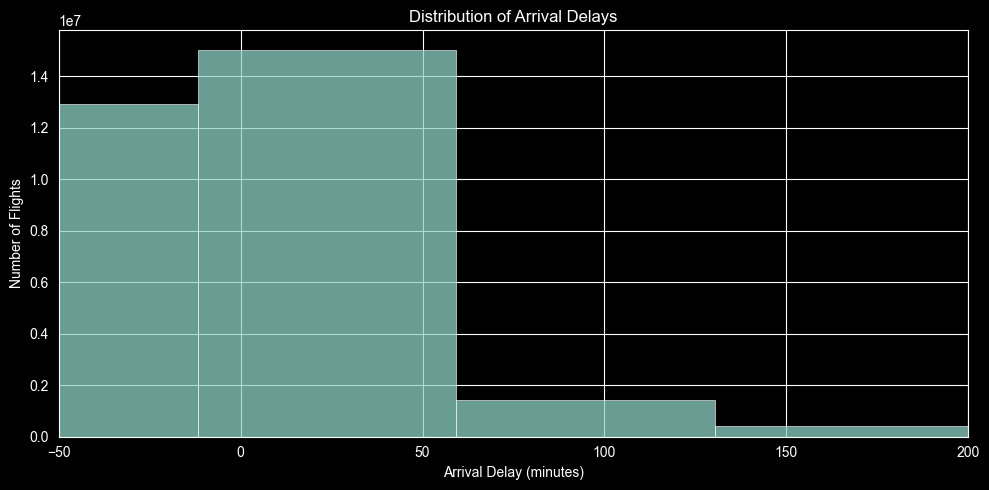

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['ArrDelay'], bins=120)
plt.xlim(-50, 200)
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

### 4.2 Average Delay by Airline

Significant variation exists across carriers. Budget and regional carriers tend to show higher average delays, while Hawaiian Airlines performs best — likely due to shorter, less congested route networks.

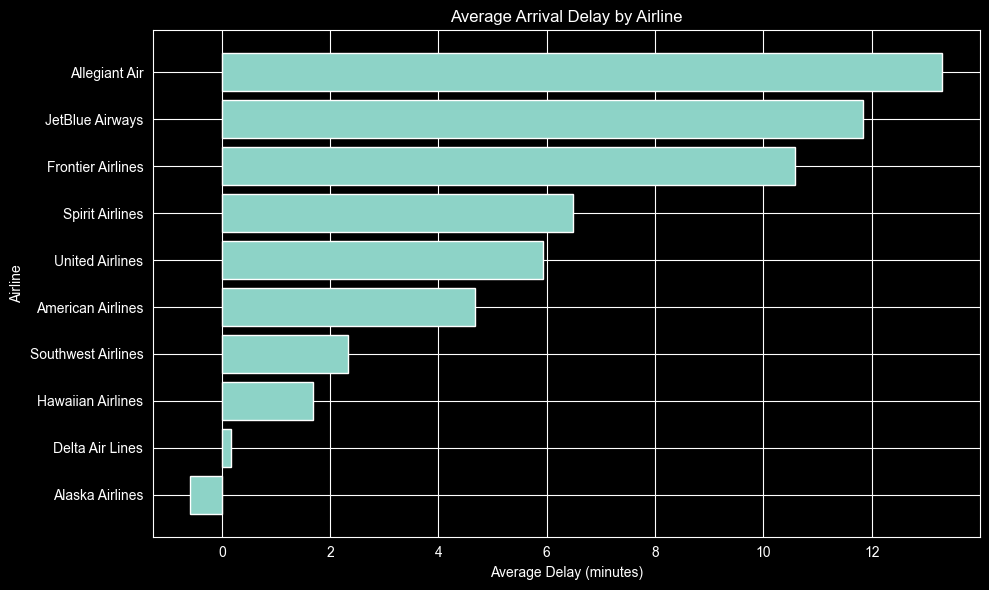

In [7]:
airline_delay = (
    df.groupby('AirlineName')['ArrDelay']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(airline_delay.index, airline_delay.values)
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

### 4.3 Average Delay by Scheduled Departure Hour

Delays accumulate throughout the day as schedule disruptions propagate. Morning departures are typically on time; evening flights bear the weight of earlier disruptions cascading through the network.

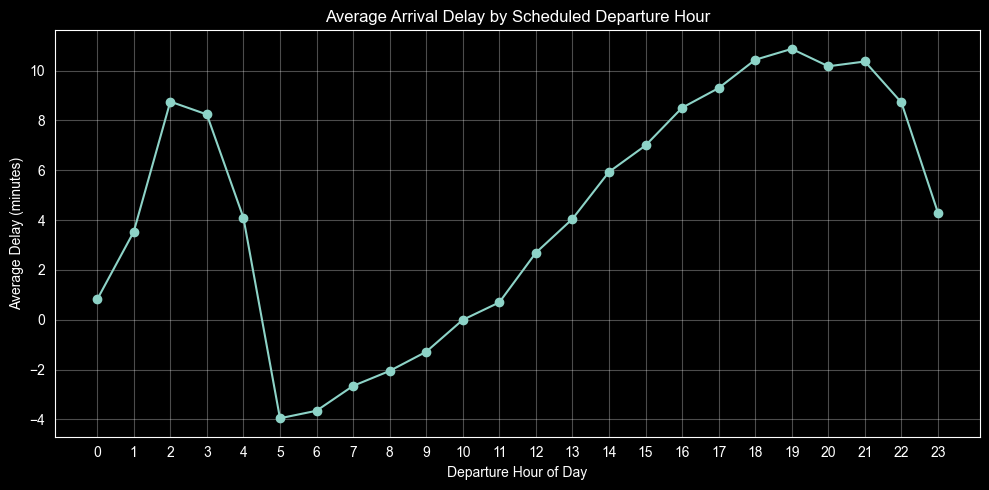

In [8]:
delay_by_hour = df.groupby('dep_hour')['ArrDelay'].mean()

plt.figure(figsize=(10, 5))
plt.plot(delay_by_hour.index, delay_by_hour.values, marker='o')
plt.title('Average Arrival Delay by Scheduled Departure Hour')
plt.xlabel('Departure Hour of Day')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Average Delay by Day of Week

Friday and Thursday tend to have the highest average delays, driven by higher travel volume. Saturday shows lower delays — counterintuitively explained by fewer business travelers and less congested airports.

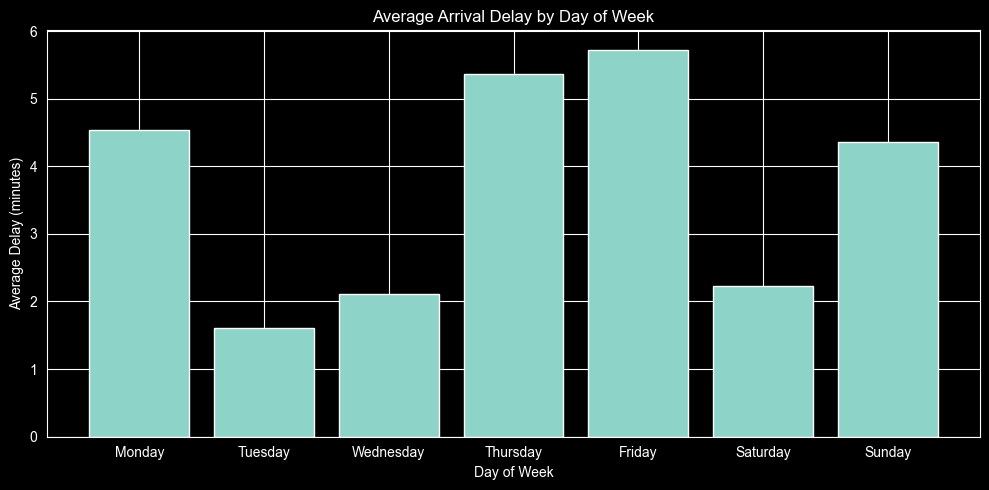

In [9]:
delay_by_day = df.groupby('day_of_week')['ArrDelay'].mean()

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
plt.bar(day_labels, delay_by_day.values)
plt.title('Average Arrival Delay by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.tight_layout()
plt.show()

### 4.5 Average Delay by Flight Distance

Longer flights generally show lower or negative arrival delays. Airlines build more buffer into long-haul schedules, and aircraft can recover time in the air. Short regional hops show the highest average delays.

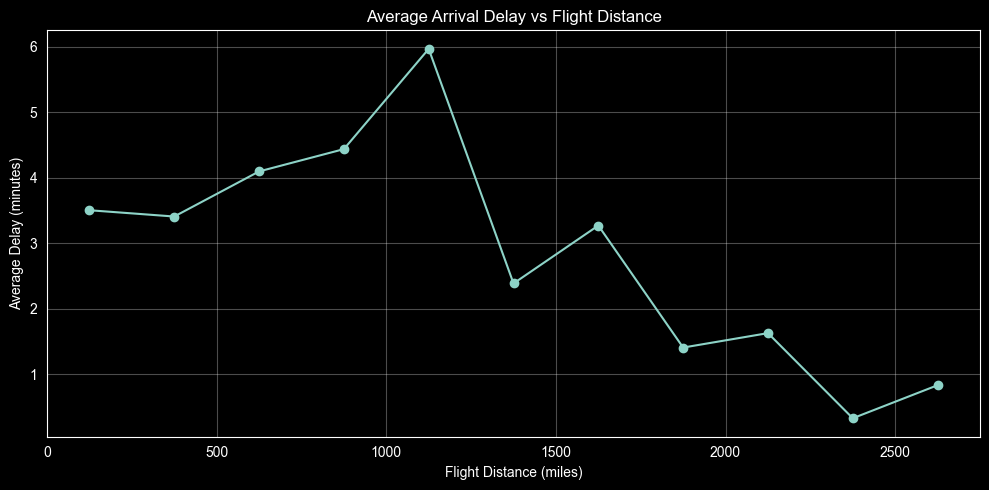

In [10]:
delay_by_distance = (
    df.groupby('DistanceGroup')['ArrDelay']
    .mean()
    .sort_index()
)
distance_midpoints = delay_by_distance.index * 250 - 125

plt.figure(figsize=(10, 5))
plt.plot(distance_midpoints, delay_by_distance.values, marker='o')
plt.title('Average Arrival Delay vs Flight Distance')
plt.xlabel('Flight Distance (miles)')
plt.ylabel('Average Delay (minutes)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Delay Cause Breakdown

Late aircraft is the dominant delay cause, reflecting cascading schedule failures. Carrier and NAS (National Aviation System) delays follow. Weather and security delays are rare on average, but weather events drive extreme outliers.

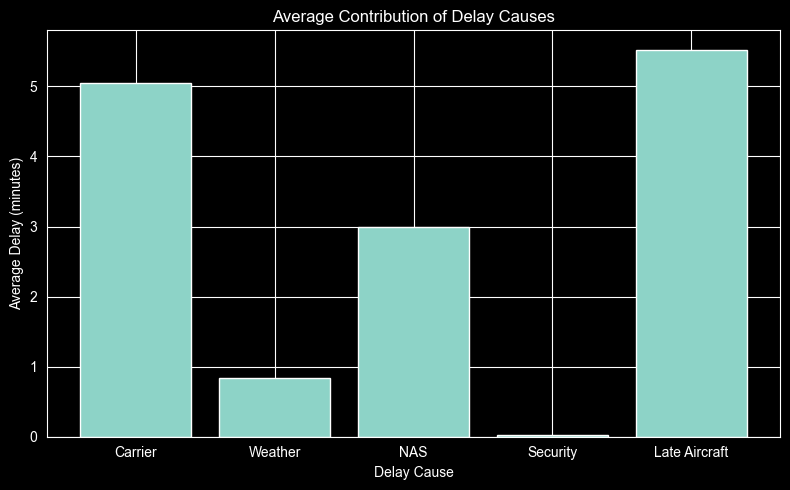

In [11]:
delay_causes = {
    'Carrier': df['CarrierDelay'].mean(),
    'Weather': df['WeatherDelay'].mean(),
    'NAS': df['NASDelay'].mean(),
    'Security': df['SecurityDelay'].mean(),
    'Late Aircraft': df['LateAircraftDelay'].mean()
}

plt.figure(figsize=(8, 5))
plt.bar(delay_causes.keys(), delay_causes.values())
plt.title('Average Contribution of Delay Causes')
plt.xlabel('Delay Cause')
plt.ylabel('Average Delay (minutes)')
plt.tight_layout()
plt.show()

### 4.7 Departure Delay vs Arrival Delay

Departure delay and arrival delay are strongly linearly correlated — a plane that leaves late generally arrives late unless it can recover time in the air. This also highlights why `DepDelay` is the dominant feature in the classification model.

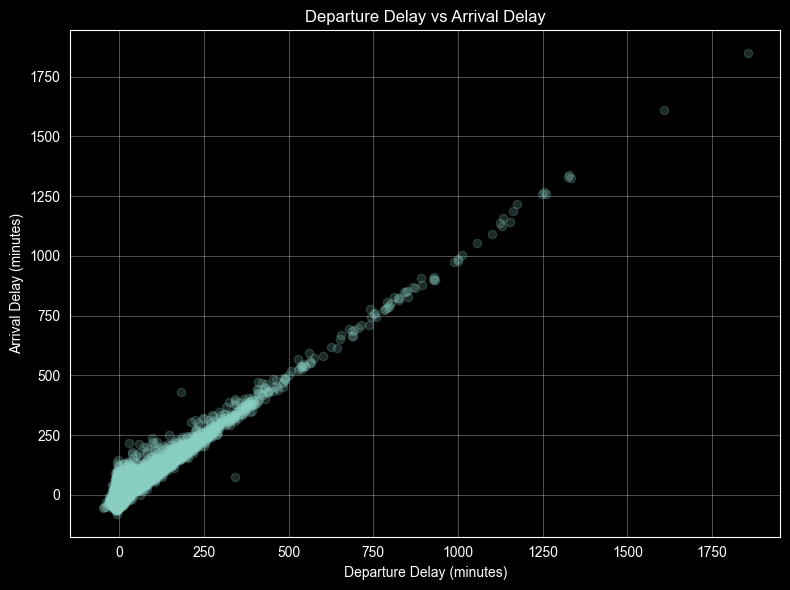

In [12]:
sample_df = df.sample(50000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_df['DepDelay'], sample_df['ArrDelay'], alpha=0.2)
plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Arrival Delay (minutes)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.8 Average Delay by Month

Delays peak in summer (June–August) and around the holidays (December). September through November is the lowest-delay period, consistent with reduced travel volume and more favorable weather.

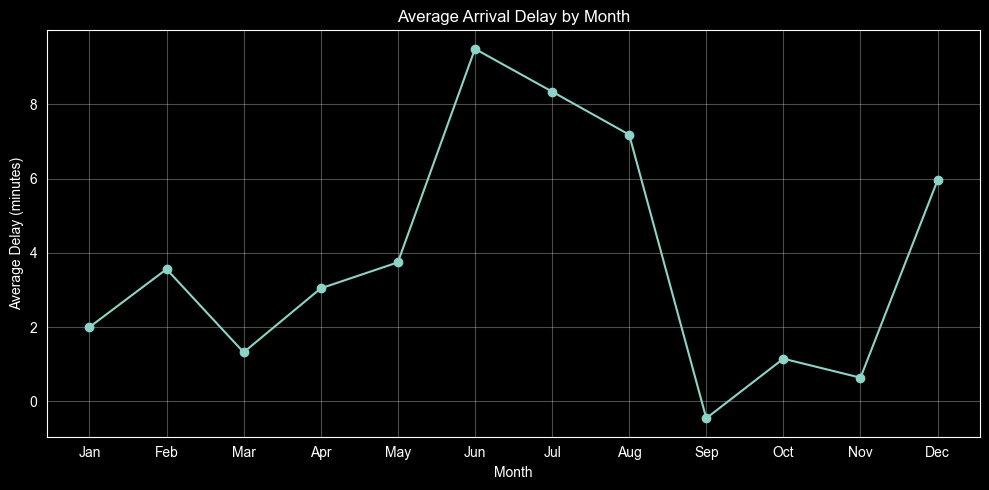

In [13]:
delay_by_month = df.groupby('month')['ArrDelay'].mean().sort_index()

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
plt.plot(delay_by_month.index, delay_by_month.values, marker='o')
plt.title('Average Arrival Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(1, 13), month_labels)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.9 Average Taxi Out Time by Departure Hour

Taxi-out times are longest during peak morning and evening departure windows, reflecting ground congestion at busy airports. This pattern closely mirrors the delay distribution by hour.

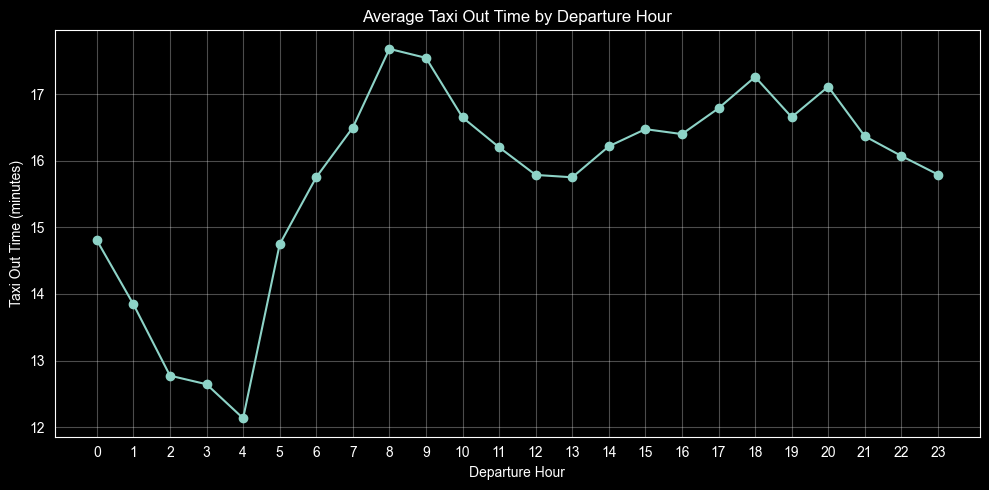

In [14]:
taxi_by_hour = df.groupby('dep_hour')['TaxiOut'].mean()

plt.figure(figsize=(10, 5))
plt.plot(taxi_by_hour.index, taxi_by_hour.values, marker='o')
plt.title('Average Taxi Out Time by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Taxi Out Time (minutes)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.10 Delay Heatmap by Day of Week and Hour

The worst delays concentrate in late evening slots (20:00–23:00) across all days, and particularly on Thursday and Friday evenings — consistent with business travel patterns and schedule propagation effects.

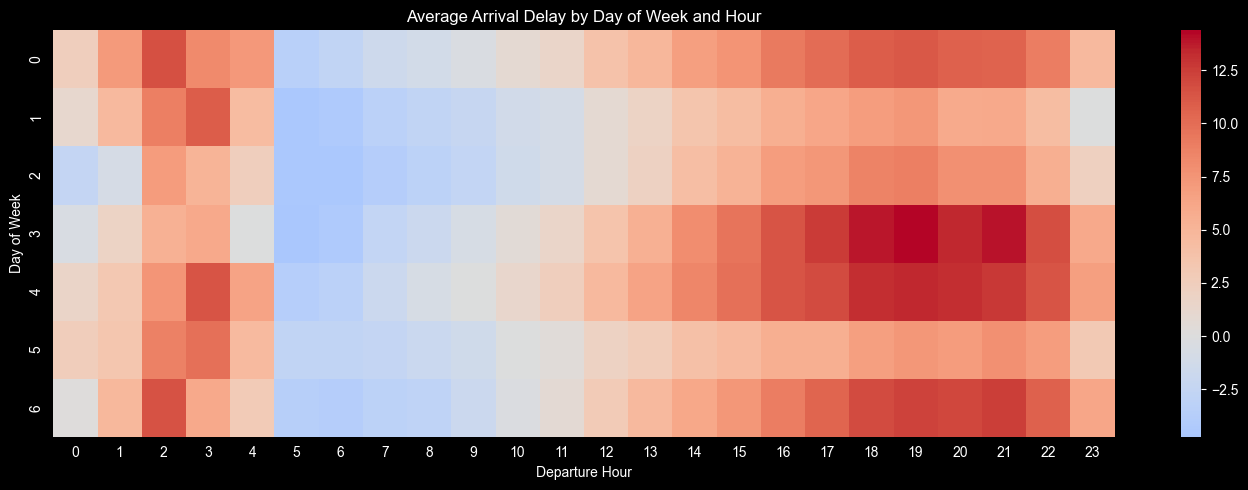

In [15]:
delay_heatmap = df.pivot_table(
    values='ArrDelay',
    index='day_of_week',
    columns='dep_hour',
    aggfunc='mean'
)

plt.figure(figsize=(14, 5))
sns.heatmap(delay_heatmap, cmap='coolwarm', center=0)
plt.title('Average Arrival Delay by Day of Week and Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

## 5. Base Feature Engineering

All modeling features are constructed in this section, organized by category. Features partially computed in Section 4.0 for EDA purposes are fully re-derived and confirmed here.

> **Note on historical/aggregate features (Section 5.7):** Aggregate statistics such as `origin_avg_delay` are computed on the full dataset. In production, these would be computed on training data only and applied as a lookup at inference time. For exploratory modeling, this global approximation is acceptable.

### 5.1 Date Features

Convert the flight date to datetime and extract calendar components.

In [16]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

df['year'] = df['FlightDate'].dt.year
df['month'] = df['FlightDate'].dt.month
df['day'] = df['FlightDate'].dt.day
df['day_of_week'] = df['FlightDate'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df[['FlightDate', 'year', 'month', 'day', 'day_of_week', 'is_weekend']].head()

,FlightDate,year,month,day,day_of_week,is_weekend
1,2018-01-15,2018,1,15,0,0
2,2018-01-16,2018,1,16,1,0
3,2018-01-17,2018,1,17,2,0
4,2018-01-18,2018,1,18,3,0
6,2018-01-20,2018,1,20,5,1


### 5.2 Time Conversion Features

Time fields in the raw data use HHMM integer format (e.g. 1430 = 2:30 PM). We convert them to total minutes since midnight for use as continuous numeric features.

In [17]:
def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    return (x // 100) * 60 + (x % 100)

time_cols = ['CRSDepTime', 'DepTime', 'CRSArrTime', 'ArrTime', 'WheelsOff', 'WheelsOn']

for col in time_cols:
    df[col + '_min'] = df[col].apply(hhmm_to_minutes)

df[[c for c in df.columns if '_min' in c]].head()

,CRSDepTime_min,DepTime_min,CRSArrTime_min,ArrTime_min,WheelsOff_min,WheelsOn_min
1,1125,1168,1268,1309,1203,1305
2,1115,1196,1258,1327,1214,1322
3,1115,1116,1258,1254,1135,1248
4,1125,1124,1268,1258,1160,1252
6,1115,1109,1258,1226,1131,1220


### 5.3 Time of Day Features

Derived from the scheduled departure time. These capture cyclical and categorical temporal context for modeling.

In [18]:
df['dep_hour'] = df['CRSDepTime_min'] // 60
df['arr_hour'] = df['CRSArrTime_min'] // 60

df['dep_period'] = pd.cut(
    df['dep_hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['night', 'morning', 'afternoon', 'evening'],
    right=False
)

df['rush_hour'] = df['dep_hour'].isin([6, 7, 8, 16, 17, 18]).astype(int)

df[['CRSDepTime_min', 'dep_hour', 'dep_period', 'rush_hour']].head()

,CRSDepTime_min,dep_hour,dep_period,rush_hour
1,1125,18,evening,1
2,1115,18,evening,1
3,1115,18,evening,1
4,1125,18,evening,1
6,1115,18,evening,1


### 5.4 Route and Airline Features

The route is encoded as an origin-destination string (underscore separator) used for frequency counts and historical delay aggregation. Airline is label-encoded for use in models. `AirlineName` (created in Section 4.0 for EDA) is confirmed here.

In [19]:
df['route'] = df['OriginCityName'] + '_' + df['DestCityName']
df['airline_code'] = df['Marketing_Airline_Network'].astype('category').cat.codes

route_frequency = df['route'].value_counts()
df['route_frequency'] = df['route'].map(route_frequency)

df[['Marketing_Airline_Network', 'AirlineName', 'route', 'airline_code', 'route_frequency']].head()

,Marketing_Airline_Network,AirlineName,route,airline_code,route_frequency
1,UA,United Airlines,"Newark, NJ_Charleston, SC",8,5919
2,UA,United Airlines,"Newark, NJ_Charleston, SC",8,5919
3,UA,United Airlines,"Newark, NJ_Charleston, SC",8,5919
4,UA,United Airlines,"Newark, NJ_Charleston, SC",8,5919
6,UA,United Airlines,"Newark, NJ_Charleston, SC",8,5919


### 5.5 Cyclical Time Features

Hour of day and day of week are cyclical: hour 23 is adjacent to hour 0. Sine/cosine encoding preserves this circular structure, which is important for linear and distance-based models.

In [20]:
df['hour_sin'] = np.sin(2 * np.pi * df['dep_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['dep_hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df[['dep_hour', 'hour_sin', 'hour_cos', 'day_of_week', 'dow_sin', 'dow_cos']].head()

,dep_hour,hour_sin,hour_cos,day_of_week,dow_sin,dow_cos
1,18,-1.0,-1.836970e-16,0,0.000000,1.000000
2,18,-1.0,-1.836970e-16,1,0.781831,0.623490
3,18,-1.0,-1.836970e-16,2,0.974928,-0.222521
4,18,-1.0,-1.836970e-16,3,0.433884,-0.900969
6,18,-1.0,-1.836970e-16,5,-0.974928,-0.222521


### 5.6 Operational Features

These capture in-flight and ground operational dynamics, derived from values known at or shortly after gate departure.

> **Leakage note:** `dep_delay_ratio`, `delay_recovered`, and `is_late_departure` depend on `DepDelay`, which is known only after the aircraft departs the gate. These are used in the classification model (where `DepDelay` is an explicit predictor) but excluded from the regression feature sets.

In [21]:
# Departure delay as a fraction of scheduled flight time
df['dep_delay_ratio'] = df['DepDelay'] / (df['CRSElapsedTime'] + 1)

# Minutes of delay recovered in the air
df['delay_recovered'] = df['DepDelay'] - df['ArrDelay']

# Binary flag: departed more than 15 minutes late
df['is_late_departure'] = (df['DepDelay'] > 15).astype(int)

# Combined taxi time and imbalance ratio
df['taxi_total'] = df['TaxiOut'] + df['TaxiIn']
df['taxi_ratio'] = df['TaxiOut'] / (df['TaxiIn'] + 1)

# Sum of reported delay cause components
df['total_reported_delay'] = (
    df['CarrierDelay'] +
    df['WeatherDelay'] +
    df['NASDelay'] +
    df['SecurityDelay'] +
    df['LateAircraftDelay']
)

# Weather delay binary flag
df['weather_delay_flag'] = (df['WeatherDelay'] > 0).astype(int)

### 5.7 Historical / Aggregate Non-Leaky Features

These features encode historical average delay performance at multiple levels of granularity: origin airport, destination airport, airline, route, and origin-hour combination. They give the model a sense of how delay-prone a given context typically is — information that could be computed offline and served as a lookup at prediction time.

> **Caveat:** These averages are computed on the full dataset here. In a production pipeline, they should be computed on training data only (e.g. via cross-fold aggregation) to prevent leakage.

In [22]:
# Airport-level historical average delays
origin_delay = df.groupby('OriginCityName')['ArrDelay'].mean()
df['origin_avg_delay'] = df['OriginCityName'].map(origin_delay)

dest_delay = df.groupby('DestCityName')['ArrDelay'].mean()
df['dest_avg_delay'] = df['DestCityName'].map(dest_delay)

# Airline-level historical average delay
airline_avg_delay = df.groupby('Marketing_Airline_Network')['ArrDelay'].mean()
df['airline_avg_delay'] = df['Marketing_Airline_Network'].map(airline_avg_delay)

# Route-level historical average delay
route_avg_delay = df.groupby('route')['ArrDelay'].mean()
df['route_avg_delay'] = df['route'].map(route_avg_delay)

In [23]:
# Airport traffic volume (proxy for congestion)
origin_traffic = df['OriginCityName'].value_counts()
df['origin_traffic'] = df['OriginCityName'].map(origin_traffic)

dest_traffic = df['DestCityName'].value_counts()
df['dest_traffic'] = df['DestCityName'].map(dest_traffic)

# Seasonal peak flags
df['is_summer_peak'] = df['month'].isin([6, 7, 8]).astype(int)
df['is_holiday_season'] = df['month'].isin([11, 12]).astype(int)

In [24]:
# Origin airport + departure hour combination (finest-grained historical feature)
airport_hour_delay = df.groupby(['OriginCityName', 'dep_hour'])['ArrDelay'].mean()

df['origin_hour'] = df['OriginCityName'] + '_' + df['dep_hour'].astype(str)
df['origin_hour_key'] = list(zip(df['OriginCityName'], df['dep_hour']))
df['origin_hour_avg_delay'] = df['origin_hour_key'].map(airport_hour_delay)

### 5.8 Engineered Feature Summary

**Date Features**
- `year`, `month`, `day`, `day_of_week`, `is_weekend`

**Time Conversion Features**
- `CRSDepTime_min`, `DepTime_min`, `CRSArrTime_min`, `ArrTime_min`, `WheelsOff_min`, `WheelsOn_min`

**Time of Day Features**
- `dep_hour`, `arr_hour`, `dep_period`, `rush_hour`

**Route and Airline Features**
- `route`, `airline_code`, `AirlineName`, `route_frequency`

**Cyclical Time Features**
- `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`

**Operational Features**
- `dep_delay_ratio`, `delay_recovered`, `is_late_departure`
- `taxi_total`, `taxi_ratio`
- `total_reported_delay`, `weather_delay_flag`

**Historical / Aggregate Non-Leaky Features**
- `origin_avg_delay`, `dest_avg_delay`, `airline_avg_delay`, `route_avg_delay`
- `origin_traffic`, `dest_traffic`
- `is_summer_peak`, `is_holiday_season`
- `origin_hour`, `origin_hour_key`, `origin_hour_avg_delay`

## 6. Modeling Strategy

This notebook approaches flight delay prediction through two complementary tasks.

### Binary Classification: Delay Occurrence
**Target:** `is_delay = (ArrDelay > 15).astype(int)`

Predicting whether a flight will be delayed by more than 15 minutes (the FAA official threshold) is a well-structured binary classification problem. The class distribution (~79% on-time, ~21% delayed) is imbalanced but manageable with standard algorithms.

### Regression: Delay Magnitude
**Target:** `ArrDelay` in minutes, clipped to `[-30, 180]` for delayed-only models

Predicting the exact delay duration is substantially harder. Delay magnitude is driven by stochastic real-time operational events — aircraft maintenance issues, cascading schedule failures, weather disruptions — that are largely invisible to pre-departure features.

### Model Progression

| Model | Task | Dataset | Algorithm |
|-------|------|---------|-----------|
| Model 1 | Classification | All flights | Logistic Regression |
| Model 2 | Regression | All flights | Linear Regression |
| Model 3 | Regression | Delayed flights only | Random Forest |
| Model 4 | Regression | Delayed flights + historical features | Random Forest (enhanced) |
| Model 5 | Regression | Delayed flights + full feature set | XGBoost |

The expected outcome is that classification significantly outperforms regression, supporting a two-stage production strategy: classify first, then estimate severity only for flights predicted as delayed.

## 7. Model 1: Delay Classification

We frame the delay prediction problem as binary classification: will a flight arrive more than 15 minutes late? This is a well-defined threshold used in official FAA delay reporting.

### 7.1 Target Definition

In [25]:
df['is_delay'] = (df['ArrDelay'] > 15).astype(int)

print('Class distribution:')
print(df['is_delay'].value_counts(normalize=True).rename({0: 'On Time', 1: 'Delayed'}))

Class distribution:
is_delay
On Time    0.792686
Delayed    0.207314
Name: proportion, dtype: float64


### 7.2 Leakage Prevention

The following columns are dropped before modeling. They contain information that is only known after the flight lands and therefore cannot be used to predict delay.

**Columns removed due to leakage:**
- `ArrDelay` — the regression target; not used here since `is_delay` is the target
- `ArrDelayMinutes` — alternative encoding of arrival delay
- `ArrTime` — actual arrival time (unknown before flight)
- `WheelsOn` — actual landing time (unknown before flight)
- `TaxiIn` — post-landing taxi time (unknown before flight)
- `ActualElapsedTime` — total actual flight duration (unknown before flight)
- `AirTime` — actual airborne time (unknown before flight)
- `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` — post-flight delay cause breakdown

In [26]:
clf_drop_cols = [
    'ArrDelay',
    'ArrDelayMinutes',
    'ArrTime',
    'WheelsOn',
    'TaxiIn',
    'ActualElapsedTime',
    'AirTime',
    'CarrierDelay',
    'WeatherDelay',
    'NASDelay',
    'SecurityDelay',
    'LateAircraftDelay'
]

df_clf = df.drop(columns=clf_drop_cols)

### 7.3 Feature Set Used

The classification model includes `DepDelay` — departure delay is known at gate departure time and is a strong predictor of arrival delay. Cyclical time encodings, route frequency, and operational features are also included.

In [27]:
clf_features = [
    'dep_hour',
    'month',
    'day_of_week',
    'is_weekend',
    'Distance',
    'DistanceGroup',
    'TaxiOut',
    'CRSElapsedTime',
    'DepDelay',
    'dep_delay_ratio',
    'rush_hour',
    'route_frequency',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'airline_code'
]

X = df_clf[clf_features]
y = df_clf['is_delay']

print(f'Features: {len(clf_features)}')
print(f'Samples:  {len(X):,}')

Features: 17
Samples:  30,132,672


### 7.4 Train-Test Split

Stratified splitting preserves the class ratio in both train and test sets.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {len(X_train):,}')
print(f'Test size:  {len(X_test):,}')

Train size: 24,106,137
Test size:  6,026,535


### 7.5 Logistic Regression Model

In [29]:
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)

clf_pred = clf_model.predict(X_test)

/Users/daniloruberti/Desktop/FlightDelays2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 7.6 Evaluation

In [30]:
print('Classification Report:')
print(classification_report(y_test, clf_pred, target_names=['On Time', 'Delayed']))

clf_probs = clf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, clf_probs)
print(f'ROC AUC Score: {auc:.4f}')

Classification Report:
              precision    recall  f1-score   support

     On Time       0.97      0.99      0.98   4777150
     Delayed       0.95      0.87      0.91   1249385

    accuracy                           0.96   6026535
   macro avg       0.96      0.93      0.94   6026535
weighted avg       0.96      0.96      0.96   6026535

ROC AUC Score: 0.9728


**Interpretation:** Logistic Regression achieves ~96% overall accuracy and a ROC AUC of ~0.97. The strong performance is largely driven by `DepDelay` — a flight that has already departed late is very likely to arrive late. Even accounting for this, the model generalizes well and correctly classifies the minority delayed class with high precision and recall. Classification is the more tractable of the two prediction tasks.

## 8. Model 2: Baseline Regression for Delay Minutes

As a baseline, we apply Linear Regression to predict `ArrDelay` across all flights. This establishes a lower bound on regression performance and quantifies how much delay variance is explained by pre-departure schedule features alone.

### 8.1 Regression Target

In [31]:
y_reg_all = df['ArrDelay'].copy()

print(f'Target stats — mean: {y_reg_all.mean():.2f}, std: {y_reg_all.std():.2f}, '
      f'min: {y_reg_all.min():.0f}, max: {y_reg_all.max():.0f}')

Target stats — mean: 3.75, std: 54.55, min: -1290, max: 7232


### 8.2 Leakage Prevention

The same post-flight columns removed in the classification model are excluded here, along with `is_delay` (the classification target derived from `ArrDelay`).

**Columns removed due to leakage:**
- `ArrDelayMinutes` — alternative encoding of `ArrDelay`
- `ArrTime`, `WheelsOn`, `TaxiIn`, `ActualElapsedTime`, `AirTime` — post-flight actuals
- `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` — post-flight breakdown
- `is_delay` — classification target derived from `ArrDelay`

In [32]:
reg_drop_cols = [
    'ArrDelayMinutes',
    'ArrTime',
    'WheelsOn',
    'TaxiIn',
    'ActualElapsedTime',
    'AirTime',
    'CarrierDelay',
    'WeatherDelay',
    'NASDelay',
    'SecurityDelay',
    'LateAircraftDelay',
    'is_delay'
]

df_reg = df.drop(columns=reg_drop_cols)

### 8.3 Feature Set Used

`DepDelay` is excluded from all regression models. Including it would approximate `ArrDelay ≈ DepDelay + constant`, which is trivially accurate but not useful for pre-departure prediction.

In [33]:
base_reg_features = [
    'dep_hour',
    'month',
    'day_of_week',
    'is_weekend',
    'Distance',
    'DistanceGroup',
    'CRSElapsedTime',
    'rush_hour',
    'route_frequency',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'airline_code'
]

X = df_reg[base_reg_features]
y = y_reg_all

print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (30132672, 14)


### 8.4 Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 8.5 Linear Regression Model

In [35]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lin_pred = lin_reg.predict(X_test)

### 8.6 Evaluation

In [36]:
rmse = np.sqrt(mean_squared_error(y_test, lin_pred))
mae = mean_absolute_error(y_test, lin_pred)
r2 = r2_score(y_test, lin_pred)

print(f'RMSE: {rmse:.2f} minutes')
print(f'MAE:  {mae:.2f} minutes')
print(f'R²:   {r2:.4f}')

RMSE: 54.30 minutes
MAE:  26.69 minutes
R²:   0.0097


**Interpretation:** The baseline linear regression achieves an R² of approximately 0.01 — effectively explaining almost none of the variance in arrival delay. The RMSE of ~54 minutes is large relative to the mean delay, illustrating that pre-departure schedule features alone have very limited power to predict exact delay duration. Delay magnitude is driven primarily by real-time stochastic events not visible in the feature set.

## 9. Model 3: Regression Only on Delayed Flights

Rather than predicting `ArrDelay` across all flights (dominated by on-time behavior), we restrict regression to flights that are actually delayed. This tests whether delay magnitude is predictable conditional on a delay occurring.

### 9.1 Rationale

Predicting delay magnitude across all flights is confounded by the ~79% of flights with near-zero or negative delays. The regression objective on that population is dominated by the on-time majority. By filtering to `ArrDelay > 15`, we focus on the operationally relevant question: given that a delay is occurring, how bad is it likely to be?

### 9.2 Dataset Filter

In [37]:
df_delay_only = df[df['ArrDelay'] > 15].copy()

print(f'Delayed flights: {len(df_delay_only):,} ({len(df_delay_only)/len(df)*100:.1f}% of total)')

Delayed flights: 6,246,922 (20.7% of total)


### 9.3 Target Capping

The target is clipped to `[-30, 180]` minutes. The lower bound handles edge cases where flights depart very late but arrive less delayed than expected. The upper bound limits the influence of catastrophic outliers (e.g. multi-hour delays due to diversions) that a model cannot realistically learn to predict from pre-departure features.

In [38]:
y = df_delay_only['ArrDelay'].clip(-30, 180)

print(f'Target after clipping — mean: {y.mean():.2f}, std: {y.std():.2f}, '
      f'min: {y.min():.0f}, max: {y.max():.0f}')

Target after clipping — mean: 60.03, std: 47.56, min: 16, max: 180


### 9.4 Feature Set Used

Same pre-departure feature set as the baseline regression model. `DepDelay` is excluded.

In [39]:
rf_base_features = [
    'dep_hour',
    'month',
    'day_of_week',
    'is_weekend',
    'Distance',
    'DistanceGroup',
    'CRSElapsedTime',
    'rush_hour',
    'route_frequency',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'airline_code'
]

X = df_delay_only[rf_base_features]

print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (6246922, 14)


### 9.5 Train-Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 9.6 Random Forest Regressor

In [41]:
rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)

### 9.7 Evaluation

In [42]:
rmse = np.sqrt(mean_squared_error(y_test, rf_base_pred))
mae = mean_absolute_error(y_test, rf_base_pred)
r2 = r2_score(y_test, rf_base_pred)

print(f'RMSE: {rmse:.2f} minutes')
print(f'MAE:  {mae:.2f} minutes')
print(f'R²:   {r2:.4f}')

RMSE: 46.74 minutes
MAE:  36.59 minutes
R²:   0.0317


**Interpretation:** Random Forest on the delayed-only subset achieves an R² of approximately 0.03 — a marginal improvement over the linear baseline but still very low. The model correctly identifies that some routes, times of day, and airlines are more delay-prone, but cannot reliably predict the specific magnitude of a given delay. The RMSE (~47 minutes) is large relative to the mean delay, confirming that delay severity is largely stochastic given pre-departure features.

## 10. Model 4: Enhanced Regression with Additional Non-Leaky Historical Features

We augment the feature set with historical aggregate statistics computed from the full dataset. These encode how delay-prone a given airport, airline, route, and time slot typically is — context that could be served as a lookup table at prediction time.

### 10.1 Additional Features Added

The following historical features are added to the base feature set:

- **`origin_avg_delay`** — Mean arrival delay at the origin airport
- **`dest_avg_delay`** — Mean arrival delay at the destination airport
- **`airline_avg_delay`** — Mean arrival delay for the operating carrier
- **`route_avg_delay`** — Mean arrival delay on the specific origin-destination route
- **`origin_traffic`** — Total flight volume at the origin airport (proxy for congestion)
- **`dest_traffic`** — Total flight volume at the destination airport

### 10.2 Feature Set Used

In [43]:
enhanced_features = [
    'dep_hour',
    'month',
    'day_of_week',
    'is_weekend',
    'Distance',
    'DistanceGroup',
    'CRSElapsedTime',
    'rush_hour',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'airline_code',
    'route_frequency',
    # Historical aggregate features
    'origin_avg_delay',
    'dest_avg_delay',
    'airline_avg_delay',
    'route_avg_delay',
    'origin_traffic',
    'dest_traffic'
]

### 10.3 Train-Test Split

In [44]:
df_delay_only = df[df['ArrDelay'] > 15].copy()

X = df_delay_only[enhanced_features]
y = df_delay_only['ArrDelay'].clip(-30, 180)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 10.4 Random Forest Regressor

A larger forest with greater depth to better leverage the expanded feature set.

In [45]:
rf_enhanced = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    n_jobs=-1,
    random_state=42
)

rf_enhanced.fit(X_train, y_train)
rf_enhanced_pred = rf_enhanced.predict(X_test)

### 10.5 Evaluation

In [46]:
rmse = np.sqrt(mean_squared_error(y_test, rf_enhanced_pred))
mae = mean_absolute_error(y_test, rf_enhanced_pred)
r2 = r2_score(y_test, rf_enhanced_pred)

print(f'RMSE: {rmse:.2f} minutes')
print(f'MAE:  {mae:.2f} minutes')
print(f'R²:   {r2:.4f}')

RMSE: 46.52 minutes
MAE:  36.38 minutes
R²:   0.0408


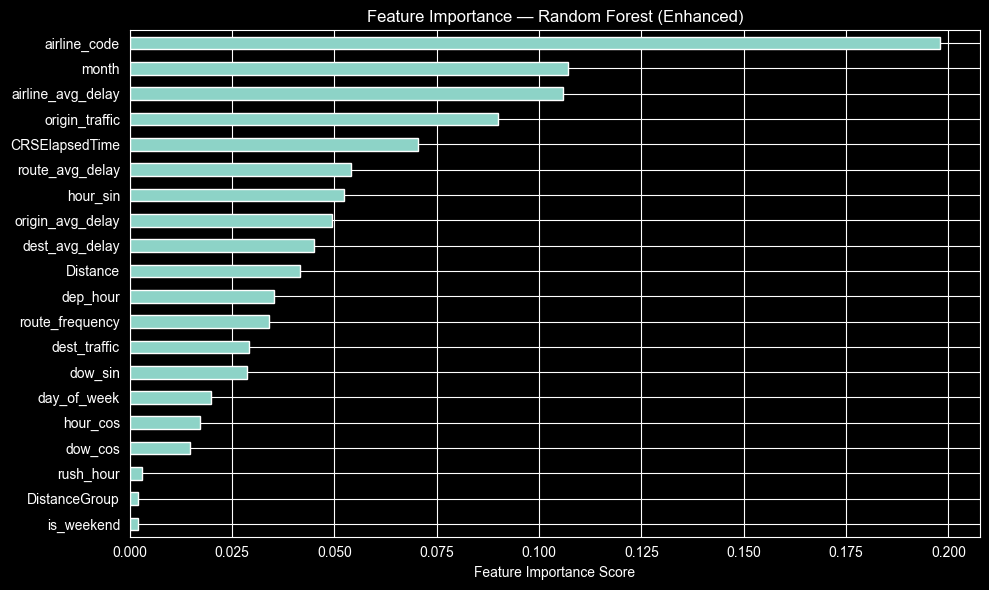

In [47]:
importance = pd.Series(rf_enhanced.feature_importances_, index=enhanced_features)
importance.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance — Random Forest (Enhanced)')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

**Interpretation:** Adding historical aggregate features yields a modest improvement (R² ~0.04 vs ~0.03). The feature importance plot reveals that route-level and airport-level historical delay statistics are among the most informative predictors, alongside departure hour and elapsed time. Despite the richer feature set, R² remains low — delay magnitude is not reliably predictable from structural features alone.

## 11. Model 5: XGBoost Regression

We replace Random Forest with XGBoost, a gradient-boosted tree ensemble that is generally more sample-efficient and faster to train on large datasets.

### 11.1 Motivation for XGBoost

XGBoost builds trees sequentially — each tree corrects the errors of the previous ensemble — whereas Random Forest builds trees in parallel with bagging. On structured tabular data, gradient boosting typically achieves better accuracy for the same number of trees. It also trains significantly faster on large datasets through native parallelism and approximate tree learning algorithms.

### 11.2 Feature Set Used

The XGBoost model uses the enhanced feature set from Model 4, plus `origin_hour_avg_delay` — the historical mean delay broken down by origin airport and departure hour. This is the finest-grained historical aggregate feature.

In [48]:
xgb_features = [
    'dep_hour',
    'month',
    'day_of_week',
    'is_weekend',
    'Distance',
    'DistanceGroup',
    'CRSElapsedTime',
    'rush_hour',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'airline_code',
    'route_frequency',
    'origin_avg_delay',
    'dest_avg_delay',
    'airline_avg_delay',
    'route_avg_delay',
    'origin_traffic',
    'dest_traffic',
    'origin_hour_avg_delay'
]

### 11.3 Train-Test Split

In [49]:
df_delay_only = df[df['ArrDelay'] > 15].copy()

X = df_delay_only[xgb_features]
y = df_delay_only['ArrDelay'].clip(-30, 180)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 11.4 XGBoost Model

In [50]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

### 11.5 Evaluation

In [51]:
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae = mean_absolute_error(y_test, xgb_pred)
r2 = r2_score(y_test, xgb_pred)

print(f'RMSE: {rmse:.2f} minutes')
print(f'MAE:  {mae:.2f} minutes')
print(f'R²:   {r2:.4f}')

RMSE: 46.33 minutes
MAE:  36.18 minutes
R²:   0.0487


**Interpretation:** XGBoost achieves an R² of approximately 0.049 — a further modest improvement over the enhanced Random Forest (R² ~0.041). Training time is substantially faster. The improvement over Random Forest is small because the fundamental challenge remains: delay magnitude is driven by real-time events not present in the feature set, not by model capacity.

### 11.6 Predicted vs Actual Delay Plot

The scatter plot shows predicted vs actual delay on the test set. A perfect model would cluster tightly around the red diagonal line.

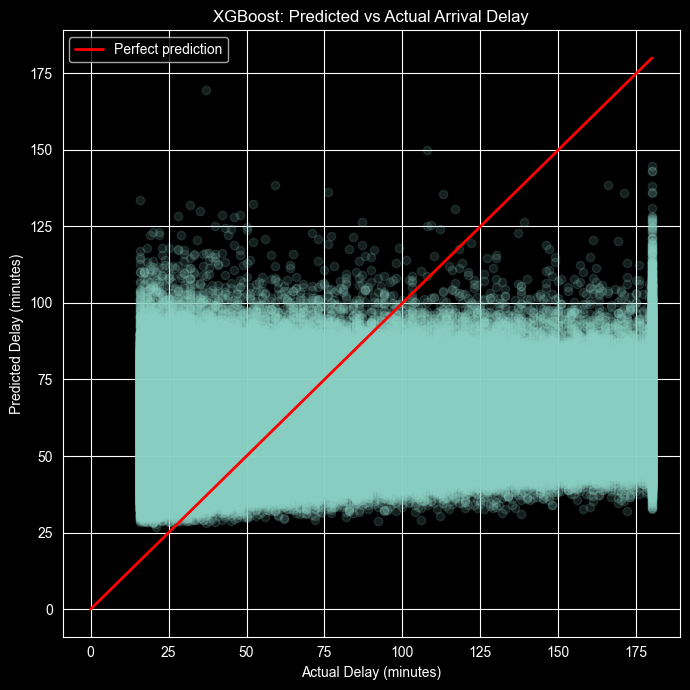

In [52]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, xgb_pred, alpha=0.15)
plt.xlabel('Actual Delay (minutes)')
plt.ylabel('Predicted Delay (minutes)')
plt.title('XGBoost: Predicted vs Actual Arrival Delay')
plt.plot([0, 180], [0, 180], color='red', linewidth=2, label='Perfect prediction')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Predictions cluster around the mean delay rather than tracking individual values closely. The model captures the broad distribution but cannot predict specific delay magnitudes. This is consistent with the low R² and confirms that delay magnitude estimation requires real-time operational data (current weather, aircraft status, crew availability) not available in historical schedule features.

## 12. Final Conclusions

### Summary of Results

| Model | Task | Metric | Score |
|-------|------|--------|-------|
| Logistic Regression | Classification | ROC AUC | 0.973 |
| Linear Regression | Regression (all flights) | R² | 0.010 |
| Random Forest | Regression (delayed only, base features) | R² | 0.032 |
| Random Forest (enhanced) | Regression (delayed only, +historical) | R² | 0.041 |
| XGBoost | Regression (delayed only, full feature set) | R² | 0.049 |

### Key Findings

1. **Classification vastly outperforms regression.** Predicting whether a flight will be delayed is a tractable problem (AUC ~0.97, accuracy ~96%). Predicting exact delay minutes is fundamentally much harder.

2. **Delay magnitude is largely stochastic.** Pre-departure structural features explain less than 5% of the variance in delay duration. The dominant drivers are real-time disruptions — maintenance issues, weather events, cascading schedule failures — invisible to the model at prediction time.

3. **Historical aggregate features help, but modestly.** Airport and route-level average delay statistics add predictive signal without using post-flight data, but cannot overcome the fundamental noise in the target.

4. **XGBoost trains significantly faster than Random Forest** at comparable or slightly better accuracy, making it the preferred algorithm for this dataset at scale.

5. **Filtering to delayed flights improves regression.** Predicting delay magnitude conditional on a delay occurring is a more focused problem and yields better relative performance than predicting across all flights.

### Recommended Production Architecture

A two-stage prediction system:

1. **Stage 1 — Classification:** Predict the probability of a delay > 15 minutes. Route to Stage 2 only for flights classified as likely delayed.

2. **Stage 2 — Severity Estimation:** Apply the XGBoost regressor (augmented with real-time operational features where available) to estimate expected delay magnitude for flagged flights.